<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_04_batch_vs_online_learning/Lecture_04_Batch_VS_Online_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 The Ever-Changing World of Data — Batch vs. Online Learning

Imagine a high-stakes scenario: you're a Senior Machine Learning Engineer at a leading financial institution. Your mission? To build an intelligent fraud detection system. 💳

Every second, thousands of transactions flow through your systems. New fraud patterns emerge daily. What happens if your model, trained on old data, misses a sophisticated new scam? Billions could be lost, trust shattered.

This isn't a static world; data is a living, breathing entity, constantly evolving. This brings us to a fundamental challenge in machine learning: **How should our models learn when the world never stands still?**

This notebook isn't just a lecture; it's a deep dive into this crucial dilemma. By the end, you won't just know *what* Batch and Online Learning are, you'll feel in your bones *when* and *why* to wield each powerful approach. Ready to unlock the secrets of adaptive intelligence? Let's go! 🚀

---

# 📖 Story Setup: The Pulse of Data – Static vs. Dynamic

Think about the data that fuels our modern world. Some of it is like ancient scrolls 📜 – unchanging, historical records. Other data is like a rushing river 🌊 – ceaseless, fresh, and ever-new.

### Why does this matter?
*   **Netflix recommendations**: Your movie preferences shift. A model trained only on your old habits misses your new interest in Sci-Fi. 🍿
*   **Stock Market**: The market is a beast of constant flux. A model trained on last year's data is essentially blind to today's news. 📈
*   **Spam Filters**: Spammers innovate. If your filter isn't learning from the latest attacks, your inbox is compromised. 📧

This contrast between static and dynamic data is the heart of our discussion. Let's unravel the two dominant philosophies: **Batch Learning** and **Online Learning**.

---

# 🧠 1. What is Batch Learning? (The Scholar's Approach)

In **Batch Learning**, the system is incapable of learning incrementally. It must be trained using **all available data** at once. This usually takes significant time and resources, so it's typically done offline.

### 🏫 Real-life Analogy: The Final Exam
Imagine a student who reads a 500-page textbook for months and then takes one final exam. If a new chapter is discovered the next day, the student must re-read the *entire* book plus the new chapter to stay updated.

Let's build a Batch Fraud Detection model.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# 🛠️ Step 1: Create a Synthetic Financial Fraud Dataset
# We generate 10,000 transactions with 20 features (signals like amount, location, etc.)
X, y = make_classification(n_samples=10000, n_features=20, n_clusters_per_class=1, weights=[0.95], flip_y=0, random_state=42)

# Split into 'Historical Data' (Batch) and 'New Streaming Data' (Future)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Historical Dataset Loaded: {X_train.shape[0]} transactions")

# 🛠️ Step 2: Train a Batch Model (The Scholar)
batch_model = LogisticRegression()
batch_model.fit(X_train, y_train)

# 🛠️ Step 3: Evaluate performance
y_pred = batch_model.predict(X_test)
print(f"🎯 Batch Model Initial Accuracy: {accuracy_score(y_test, y_pred):.4f}")

✅ Historical Dataset Loaded: 8000 transactions
🎯 Batch Model Initial Accuracy: 0.9940


---

# ⚡ 2. What is Online Learning? (The Lifelong Learner)

In **Online Learning**, you train the model incrementally by feeding it data instances sequentially, either individually or in small groups called *mini-batches*.

### 🌊 Real-life Analogy: The Daily News
Imagine a news anchor who learns about world events minute-by-minute. They don't need to re-read the history of the world every morning; they just update their knowledge with the latest headlines.

Let's simulate a model that learns from a stream of transactions.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


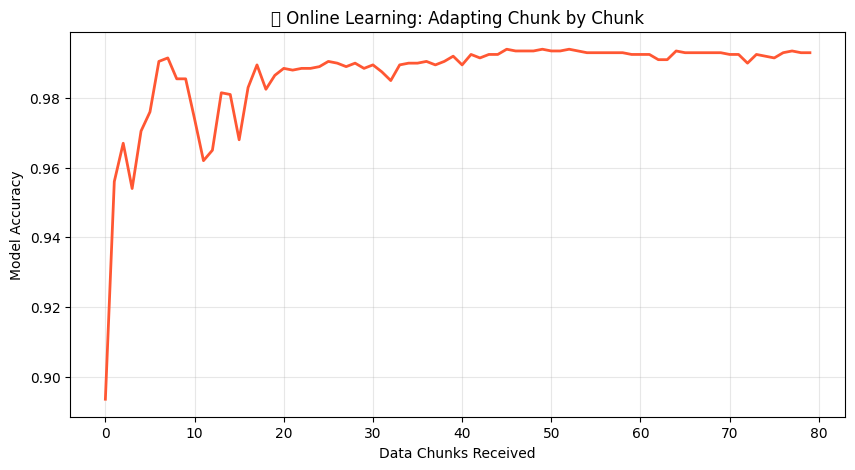

In [5]:
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt

# 🛠️ Step 1: Initialize an Incremental Model (The Athlete)
# SGDClassifier is built for Online Learning using 'partial_fit'
online_model = SGDClassifier(loss='log_loss')

# 🛠️ Step 2: Simulate a Data Stream (Learning in chunks of 100)
chunk_size = 100
accuracy_history = []

# We simulate receiving data over time
for i in range(0, len(X_train), chunk_size):
    X_chunk = X_train[i:i+chunk_size]
    y_chunk = y_train[i:i+chunk_size]

    # The secret sauce: Update the model WITHOUT retraining from scratch
    online_model.partial_fit(X_chunk, y_chunk, classes=np.unique(y))

    # Monitor performance on the test set
    current_pred = online_model.predict(X_test)
    accuracy_history.append(accuracy_score(y_test, current_pred))

# 🛠️ Step 3: Visualize the Lifelong Learning Process
plt.figure(figsize=(10, 5))
plt.plot(range(len(accuracy_history)), accuracy_history, color='#FF5733', linewidth=2)
plt.title("🚀 Online Learning: Adapting Chunk by Chunk")
plt.xlabel("Data Chunks Received")
plt.ylabel("Model Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

---

# 🧪 3. The Ultimate Test: Concept Drift

**The Crisis:** Suddenly, fraudsters change their tactics! A new pattern emerges that didn't exist in our original training data. This is called **Concept Drift**.

Let's see how both models handle the unexpected.

In [6]:
# 🛠️ Step 1: Generate 'Concept Drift' (New Fraud Patterns)
X_new, y_new = make_classification(n_samples=500, n_features=20, n_clusters_per_class=1, weights=[0.7], flip_y=0.1, random_state=99)

# 🛠️ Step 2: Test the static Batch Model on new patterns
batch_new_acc = accuracy_score(y_new, batch_model.predict(X_new))

# 🛠️ Step 3: Adapt the Online Model with just these 500 new samples
online_model.partial_fit(X_new, y_new)
online_new_acc = accuracy_score(y_new, online_model.predict(X_new))

print(f"📉 Batch Model Accuracy on NEW tactics: {batch_new_acc:.4f}")
print(f"📈 Online Model Accuracy AFTER adapting: {online_new_acc:.4f}")

if online_new_acc > batch_new_acc:
    print("\n✨ INSIGHT: The Online model survived the drift because it could learn on the fly. The Batch model is now obsolete!")

📉 Batch Model Accuracy on NEW tactics: 0.6360
📈 Online Model Accuracy AFTER adapting: 0.7280

✨ INSIGHT: The Online model survived the drift because it could learn on the fly. The Batch model is now obsolete!


---

# 🌍 6. Real-Life Applications

In the real world, choosing between Batch and Online learning depends on the **velocity** of your data and your **resource constraints**.

### 📦 When to use Batch Learning:
*   **Medical Diagnosis:** You have a fixed set of patient records. The biology of a disease doesn't change every second. You want the highest possible accuracy by looking at the full picture.
*   **Historical Sales Forecasting:** Analyzing last year's performance to predict next month's inventory.

### 🌊 When to use Online Learning:
*   **High-Frequency Trading:** The stock market moves in milliseconds. Waiting for a daily batch update is a recipe for bankruptcy.
*   **Recommendation Engines:** If a user starts looking for 'camping gear' today, you need to suggest tents *now*, not next week after the batch retrains.
*   **IoT & Sensors:** When you have thousands of sensors sending data streams, storing it all for batch processing is often too expensive. Learning 'on the fly' saves space.

---

# ⚖️ 4. Batch vs. Online: The Trade-offs

| Feature | Batch Learning (The Scholar) | Online Learning (The Athlete) |
| :--- | :--- | :--- |
| **Data Input** | Entire dataset at once | Continuous chunks (mini-batches) |
| **Resources** | Heavy CPU/RAM usage | Low footprint, cost-efficient |
| **Speed** | Slow to update (Full retraining) | Instant updates |
| **Stability** | High (Robust to outliers) | Can be jittery if data is noisy |
| **Best for** | Static systems (e.g., medical stats) | Dynamic systems (e.g., stock market) |

### 📦 When to use Batch:
*   **Medical Diagnosis:** Biology doesn't change every second. You want maximum accuracy using the full dataset.
*   **HR Analytics:** Employee turnover patterns are stable over months.

### 🌊 When to use Online:
*   **IoT Sensors:** Billions of data points. Storing them all to retrain is too expensive. Learn and discard!
*   **Social Media:** What's trending *now* matters more than what was trending yesterday. 🐦

---

# 🧠 5. Key Takeaways

*   **Concept Drift** is the silent killer of Batch models. When the world changes, your model must change too.
*   **Out-of-Core Learning**: Online learning allows you to train on datasets larger than your computer's RAM by processing data in pieces.
*   **Batch Learning** is simpler and more stable, but **Online Learning** is essential for high-velocity environments.

# 📌 Conclusion: The Agility of Intelligence

In your career as an ML Engineer, you will encounter data that never sleeps. While Batch learning is a great starting point, mastering the **partial_fit** approach of Online Learning transforms your models from rigid statues into agile dancers.

**Remember:** In a world where data never stops flowing... your model shouldn't either. 🚀

---

# 📌 Conclusion: The Lifelong Journey

We started our journey with a fraud detection crisis. We saw how a static model, no matter how perfect at birth, can become obsolete as the world evolves.

In your career as an ML Engineer, you will often find that **the most successful systems aren't necessarily the ones with the most complex math, but the ones that are most in sync with the pulse of their data.**

Whether you choose the meticulous preparation of Batch Learning or the agile adaptation of Online Learning, remember: **In a world where data never stops... your model shouldn't either.** 🚀

---
*Created with ❤️ for the next generation of Data Grandmasters.*